In [1]:
from pathlib import Path
import pandas as pd

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/raw/Interactivity Tests in Sweden - 2023")

print(DATA_PATH.exists())

True


In [3]:
egaming_files = list(DATA_PATH.rglob("*egaming*.csv"))

print("Total eGaming CSV files:", len(egaming_files))

for file in egaming_files[:10]:
    print(file)

Total eGaming CSV files: 158
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_ch_tt_tti_0.csv
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_ch_tt_tti_1.csv
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_ch_tt_tti_lte_only_0.csv
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_it_tt_tti_0.csv
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_it_tt_tti_1.csv
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_it_tt_tti_lte_only_0.csv
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_se-k_tt_tti_0.csv
..\data\raw\Interactivity T

In [5]:
### Select only 5G NSA eGaming files
### LTE-only files contain "lte_only" in their filename

egaming_5g_files = [
    f for f in egaming_files
    if "lte_only" not in f.name.lower()
]

lte_files = [
    f for f in egaming_files
    if "lte_only" in f.name.lower()
]

print("Total eGaming files:", len(egaming_files))
print("5G NSA eGaming files:", len(egaming_5g_files))
print("LTE-only eGaming files:", len(lte_files))

Total eGaming files: 158
5G NSA eGaming files: 118
LTE-only eGaming files: 40


In [6]:
from collections import Counter

scenario_count = Counter()

for file in egaming_5g_files:
    name = file.name.lower()

    if "_is_" in name:
        scenario_count["Indoor Static"] += 1
    elif "_od_" in name:
        scenario_count["Outdoor Driving"] += 1
    elif "_ow_" in name:
        scenario_count["Outdoor Walking"] += 1

print("5G eGaming files by scenario:")
for scenario, count in scenario_count.items():
    print(f"{scenario}: {count}")

5G eGaming files by scenario:
Indoor Static: 61
Outdoor Driving: 14
Outdoor Walking: 43


In [7]:
### Inspect the first 5G NSA eGaming file

sample_file = egaming_5g_files[0]

print("File:")
print(sample_file)

df_sample = pd.read_csv(sample_file)

print("\nShape:")
print(df_sample.shape)

print("\nFirst 10 rows:")
display(df_sample.head(10))

print("\nColumn names:")
for i, col in enumerate(df_sample.columns):
    print(i, ":", col)

File:
..\data\raw\Interactivity Tests in Sweden - 2023\Indoor Static Scenario\sweden_location_11_is_interactivity_egaming_ch_tt_tti_0.csv

Shape:
(680, 1)

First 10 rows:


,[DESCRIPTION]
0,Timestamp [hh:mm:ss.ss]
1,QoS Tester\Ping Result\Ping Start Time [ms] : [1]
2,QoS Tester\Ping Result\Ping End Time [ms] : [1]
3,QoS Tester\Ping Response\RTT [ms] : [1]
4,QoS Tester\QP Interactivity Progress\Cur. Pack...
5,QoS Tester\QP Interactivity Progress\Cur. Roun...
6,QoS Tester\QP Interactivity Progress\Cur. Roun...
7,QoS Tester\QP Interactivity Progress\Cur. Pack...
8,QoS Tester\QP Interactivity Progress\Cur. Pack...
9,QoS Tester\QP Interactivity Progress\Cur. Thro...



Column names:
0 : [DESCRIPTION]


In [9]:
### Show every row that may indicate the start of actual data
for i, value in enumerate(df_sample.iloc[:, 0]):
    text = str(value)

    if any(keyword in text.upper() for keyword in [
        "[DATA]", "[RESULT]", "[MEASUREMENT]", "TIMESTAMP"
    ]):
        print(i, ":", text)

0 : Timestamp [hh:mm:ss.ss]
45 : [DATA]


In [10]:
# Show rows 40 to 100
for i in range(40, min(100, len(df_sample))):
    print(i, ":", df_sample.iloc[i, 0])

40 : QoS Tester\QP Interactivity Result\Packet Delay Variation (99.9th percentile) [ms] : [2]
41 : QoS Tester\QP Interactivity Result\Throughput UL [MBit/s] : [2]
42 : QoS Tester\QP Interactivity Result\Throughput DL [MBit/s] : [2]
43 : QoS Tester\QP Interactivity Result\Interactivity Score [%] : [2]
44 : QoS Tester\QP Interactivity Result\Interactivity Result : [2]
45 : [DATA]
46 : 03:37:17.867;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;57093;57243;33.700;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?
47 : 03:37:18.891;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;57093;58267;57.100;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?
48 : 03:37:19.922;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;57093;59298;85.600;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?
49 : 03:37:20.901;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;57093;60277;64.300;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?
50 : 03:37:21.307;60498;60683;14.200;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?;?
51 : 03:37:21.891;?;?;?;

In [13]:
from io import StringIO

# Read the complete file as text
with open(sample_file, "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

# Find the [DATA] section
data_start = None

for i, line in enumerate(lines):
    if line.strip() == "[DATA]":
        data_start = i + 1
        break

print("Data starts at line:", data_start)

# Keep only the actual measurement rows
data_lines = lines[data_start:]

# Convert the data section into a DataFrame
raw = pd.read_csv(
    StringIO("".join(data_lines)),
    sep=";",
    header=None,
    dtype=str
)

print("Shape:", raw.shape)

display(raw.head())

Data starts at line: 49
Shape: (634, 45)


,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
0,03:37:17.867,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
1,03:37:18.891,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
2,03:37:19.922,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
3,03:37:20.901,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
4,03:37:21.307,60498,60683,14.200,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?


In [15]:
print("Number of columns:", raw.shape[1])

for i in range(raw.shape[1]):
    print(i, ":", raw.iloc[0, i])

Number of columns: 45
0 : 03:37:17.867
1 : ?
2 : ?
3 : ?
4 : ?
5 : ?
6 : ?
7 : ?
8 : ?
9 : ?
10 : ?
11 : ?
12 : ?
13 : ?
14 : ?
15 : ?
16 : ?
17 : ?
18 : ?
19 : ?
20 : ?
21 : ?
22 : ?
23 : 57093
24 : 57243
25 : 33.700
26 : ?
27 : ?
28 : ?
29 : ?
30 : ?
31 : ?
32 : ?
33 : ?
34 : ?
35 : ?
36 : ?
37 : ?
38 : ?
39 : ?
40 : ?
41 : ?
42 : ?
43 : ?
44 : ?


In [16]:
# Create proper column names

column_names = [
    "timestamp",

    # Operator 1
    "op1_ping_start_ms",
    "op1_ping_end_ms",
    "op1_rtt_ms",
    "op1_cur_packet_loss_pct",
    "op1_cur_latency_median_ms",
    "op1_cur_latency_p10_ms",
    "op1_cur_pdv_median_ms",
    "op1_cur_pdv_p99_9_ms",
    "op1_cur_throughput_ul_mbps",
    "op1_cur_throughput_dl_mbps",
    "op1_cur_interactivity_score_pct",
    "op1_packet_loss_pct",
    "op1_packet_discarded_pct",
    "op1_packet_error_pct",
    "op1_latency_median_ms",
    "op1_latency_p10_ms",
    "op1_pdv_median_ms",
    "op1_pdv_p99_9_ms",
    "op1_throughput_ul_mbps",
    "op1_throughput_dl_mbps",
    "op1_interactivity_score_pct",
    "op1_interactivity_result",

    # Operator 2
    "op2_ping_start_ms",
    "op2_ping_end_ms",
    "op2_rtt_ms",
    "op2_cur_packet_loss_pct",
    "op2_cur_latency_median_ms",
    "op2_cur_latency_p10_ms",
    "op2_cur_pdv_median_ms",
    "op2_cur_pdv_p99_9_ms",
    "op2_cur_throughput_ul_mbps",
    "op2_cur_throughput_dl_mbps",
    "op2_cur_interactivity_score_pct",
    "op2_packet_loss_pct",
    "op2_packet_discarded_pct",
    "op2_packet_error_pct",
    "op2_latency_median_ms",
    "op2_latency_p10_ms",
    "op2_pdv_median_ms",
    "op2_pdv_p99_9_ms",
    "op2_throughput_ul_mbps",
    "op2_throughput_dl_mbps",
    "op2_interactivity_score_pct",
    "op2_interactivity_result"
]

print("Number of column names:", len(column_names))
print("Number of data columns:", raw.shape[1])

assert len(column_names) == raw.shape[1]

raw.columns = column_names

display(raw.head())

Number of column names: 45
Number of data columns: 45


,timestamp,op1_ping_start_ms,op1_ping_end_ms,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_latency_p10_ms,op1_cur_pdv_median_ms,op1_cur_pdv_p99_9_ms,op1_cur_throughput_ul_mbps,...,op2_packet_discarded_pct,op2_packet_error_pct,op2_latency_median_ms,op2_latency_p10_ms,op2_pdv_median_ms,op2_pdv_p99_9_ms,op2_throughput_ul_mbps,op2_throughput_dl_mbps,op2_interactivity_score_pct,op2_interactivity_result
0,03:37:17.867,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
1,03:37:18.891,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
2,03:37:19.922,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
3,03:37:20.901,?,?,?,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?
4,03:37:21.307,60498,60683,14.200,?,?,?,?,?,?,...,?,?,?,?,?,?,?,?,?,?


In [17]:
import numpy as np

raw = raw.replace("?", np.nan)

print("Total missing values:", raw.isna().sum().sum())

Total missing values: 22493


In [18]:
# Convert all measurement columns to numeric
for col in raw.columns[1:]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

print(raw.dtypes)

timestamp                              str
op1_ping_start_ms                  float64
op1_ping_end_ms                    float64
op1_rtt_ms                         float64
op1_cur_packet_loss_pct            float64
op1_cur_latency_median_ms          float64
op1_cur_latency_p10_ms             float64
op1_cur_pdv_median_ms              float64
op1_cur_pdv_p99_9_ms               float64
op1_cur_throughput_ul_mbps         float64
op1_cur_throughput_dl_mbps         float64
op1_cur_interactivity_score_pct    float64
op1_packet_loss_pct                float64
op1_packet_discarded_pct           float64
op1_packet_error_pct               float64
op1_latency_median_ms              float64
op1_latency_p10_ms                 float64
op1_pdv_median_ms                  float64
op1_pdv_p99_9_ms                   float64
op1_throughput_ul_mbps             float64
op1_throughput_dl_mbps             float64
op1_interactivity_score_pct        float64
op1_interactivity_result           float64
op2_ping_st

In [19]:
print("Shape:", raw.shape)

display(raw.head(10))

print("\nMissing values:")
display(raw.isna().sum())

Shape: (634, 45)


,timestamp,op1_ping_start_ms,op1_ping_end_ms,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_latency_p10_ms,op1_cur_pdv_median_ms,op1_cur_pdv_p99_9_ms,op1_cur_throughput_ul_mbps,...,op2_packet_discarded_pct,op2_packet_error_pct,op2_latency_median_ms,op2_latency_p10_ms,op2_pdv_median_ms,op2_pdv_p99_9_ms,op2_throughput_ul_mbps,op2_throughput_dl_mbps,op2_interactivity_score_pct,op2_interactivity_result
0,03:37:17.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03:37:18.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03:37:19.922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,03:37:20.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,03:37:21.307,60498.0,60683.0,14.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,03:37:21.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,03:37:22.320,60498.0,61696.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,03:37:22.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,03:37:23.324,60498.0,62700.0,29.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,03:37:23.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


timestamp                            0
op1_ping_start_ms                  614
op1_ping_end_ms                    614
op1_rtt_ms                         614
op1_cur_packet_loss_pct            364
op1_cur_latency_median_ms          337
op1_cur_latency_p10_ms             337
op1_cur_pdv_median_ms              337
op1_cur_pdv_p99_9_ms               337
op1_cur_throughput_ul_mbps         337
op1_cur_throughput_dl_mbps         337
op1_cur_interactivity_score_pct    337
op1_packet_loss_pct                608
op1_packet_discarded_pct           608
op1_packet_error_pct               607
op1_latency_median_ms              608
op1_latency_p10_ms                 608
op1_pdv_median_ms                  608
op1_pdv_p99_9_ms                   608
op1_throughput_ul_mbps             608
op1_throughput_dl_mbps             608
op1_interactivity_score_pct        608
op1_interactivity_result           634
op2_ping_start_ms                  614
op2_ping_end_ms                    614
op2_rtt_ms               

In [20]:
print(raw.shape)
display(raw.head())

(634, 45)


,timestamp,op1_ping_start_ms,op1_ping_end_ms,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_latency_p10_ms,op1_cur_pdv_median_ms,op1_cur_pdv_p99_9_ms,op1_cur_throughput_ul_mbps,...,op2_packet_discarded_pct,op2_packet_error_pct,op2_latency_median_ms,op2_latency_p10_ms,op2_pdv_median_ms,op2_pdv_p99_9_ms,op2_throughput_ul_mbps,op2_throughput_dl_mbps,op2_interactivity_score_pct,op2_interactivity_result
0,03:37:17.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03:37:18.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03:37:19.922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,03:37:20.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,03:37:21.307,60498.0,60683.0,14.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Check how much data is available in each column

availability = pd.DataFrame({
    "non_missing": raw.notna().sum(),
    "missing": raw.isna().sum(),
    "missing_percent": (raw.isna().mean() * 100).round(2)
})

display(availability)

,non_missing,missing,missing_percent
timestamp,634,0,0.00
op1_ping_start_ms,20,614,96.85
op1_ping_end_ms,20,614,96.85
op1_rtt_ms,20,614,96.85
op1_cur_packet_loss_pct,270,364,57.41
op1_cur_latency_median_ms,297,337,53.15
op1_cur_latency_p10_ms,297,337,53.15
op1_cur_pdv_median_ms,297,337,53.15
op1_cur_pdv_p99_9_ms,297,337,53.15
op1_cur_throughput_ul_mbps,297,337,53.15


In [22]:
# Check the important QoS and QoE columns

important_cols = [
    "timestamp",
    "op1_rtt_ms",
    "op1_cur_packet_loss_pct",
    "op1_cur_latency_median_ms",
    "op1_cur_pdv_median_ms",
    "op1_cur_throughput_ul_mbps",
    "op1_cur_throughput_dl_mbps",
    "op1_cur_interactivity_score_pct",
    "op1_interactivity_score_pct",
]

display(raw[important_cols].head(20))

,timestamp,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_pdv_median_ms,op1_cur_throughput_ul_mbps,op1_cur_throughput_dl_mbps,op1_cur_interactivity_score_pct,op1_interactivity_score_pct
0,03:37:17.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03:37:18.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03:37:19.922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,03:37:20.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,03:37:21.307,14.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,03:37:21.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,03:37:22.320,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,03:37:22.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,03:37:23.324,29.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,03:37:23.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Check Interactivity Score availability

print("Operator 1 Interactivity Score:")
print(raw["op1_interactivity_score_pct"].notna().sum(), "valid values")

print("\nOperator 2 Interactivity Score:")
print(raw["op2_interactivity_score_pct"].notna().sum(), "valid values")

Operator 1 Interactivity Score:
26 valid values

Operator 2 Interactivity Score:
27 valid values


In [24]:
### Check rows where Operator 1 Interactivity Score is available

score_rows = raw[
    raw["op1_interactivity_score_pct"].notna()
][[
    "timestamp",
    "op1_rtt_ms",
    "op1_cur_packet_loss_pct",
    "op1_cur_latency_median_ms",
    "op1_cur_pdv_median_ms",
    "op1_cur_throughput_ul_mbps",
    "op1_cur_throughput_dl_mbps",
    "op1_cur_interactivity_score_pct"
]]

print("Number of QoE observations:", len(score_rows))

display(score_rows)


Number of QoE observations: 26


,timestamp,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_pdv_median_ms,op1_cur_throughput_ul_mbps,op1_cur_throughput_dl_mbps,op1_cur_interactivity_score_pct
41,03:38:02.452,NaN,NaN,0.0,0.0,0.0,0.0,0.0
63,03:38:21.456,NaN,NaN,0.0,0.0,0.0,0.0,0.0
85,03:38:39.896,NaN,NaN,0.0,0.0,0.0,0.0,0.0
107,03:38:58.986,NaN,NaN,0.0,0.0,0.0,0.0,0.0
129,03:39:17.661,NaN,NaN,0.0,0.0,0.0,0.0,0.0
151,03:39:36.480,NaN,NaN,0.0,0.0,0.0,0.0,0.0
173,03:39:54.861,NaN,NaN,0.0,0.0,0.0,0.0,0.0
195,03:40:13.405,NaN,NaN,0.0,0.0,0.0,0.0,0.0
216,03:40:32.015,NaN,NaN,0.0,0.0,0.0,0.0,0.0
239,03:40:51.011,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [26]:
### Check the actual QoE values

print("QoE values:")
print(
    raw.loc[
        raw["op1_interactivity_score_pct"].notna(),
        ["timestamp", "op1_interactivity_score_pct"]
    ].to_string(index=False)
)

QoE values:
   timestamp  op1_interactivity_score_pct
03:38:02.452                         78.7
03:38:21.456                         79.9
03:38:39.896                         80.4
03:38:58.986                         79.6
03:39:17.661                         79.8
03:39:36.480                         77.4
03:39:54.861                         78.5
03:40:13.405                         77.3
03:40:32.015                         77.7
03:40:51.011                         77.1
03:41:09.978                         78.2
03:41:28.879                         78.0
03:41:48.073                         80.1
03:42:06.788                         79.6
03:42:25.701                         80.4
03:43:16.259                         79.9
03:43:34.904                         78.0
03:43:53.797                         80.2
03:44:12.552                         77.8
03:44:31.262                         80.6
03:44:50.379                         80.4
03:45:09.186                         80.4
03:45:27.799          

In [27]:
### Check Operator 2 QoE observations

op2_scores = raw[
    raw["op2_interactivity_score_pct"].notna()
][[
    "timestamp",
    "op2_rtt_ms",
    "op2_cur_packet_loss_pct",
    "op2_cur_latency_median_ms",
    "op2_cur_pdv_median_ms",
    "op2_cur_throughput_ul_mbps",
    "op2_cur_throughput_dl_mbps",
    "op2_cur_interactivity_score_pct"
]]

print("Operator 2 QoE observations:", len(op2_scores))

display(op2_scores)

Operator 2 QoE observations: 27


,timestamp,op2_rtt_ms,op2_cur_packet_loss_pct,op2_cur_latency_median_ms,op2_cur_pdv_median_ms,op2_cur_throughput_ul_mbps,op2_cur_throughput_dl_mbps,op2_cur_interactivity_score_pct
39,03:38:01.017,NaN,NaN,0.0,0.0,0.0,0.0,0.0
61,03:38:19.516,NaN,NaN,0.0,0.0,0.0,0.0,0.0
83,03:38:38.405,NaN,NaN,0.0,0.0,0.0,0.0,0.0
105,03:38:57.285,NaN,NaN,0.0,0.0,0.0,0.0,0.0
127,03:39:16.474,NaN,NaN,0.0,0.0,0.0,0.0,0.0
149,03:39:35.446,NaN,NaN,0.0,0.0,0.0,0.0,0.0
172,03:39:54.069,NaN,NaN,0.0,0.0,0.0,0.0,0.0
194,03:40:13.112,NaN,NaN,0.0,0.0,0.0,0.0,0.0
217,03:40:32.089,NaN,NaN,0.0,0.0,0.0,0.0,0.0
238,03:40:50.619,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [28]:
print(
    raw.loc[
        raw["op2_interactivity_score_pct"].notna(),
        ["timestamp", "op2_interactivity_score_pct"]
    ].to_string(index=False)
)

   timestamp  op2_interactivity_score_pct
03:38:01.017                         64.5
03:38:19.516                         63.9
03:38:38.405                         60.0
03:38:57.285                         64.6
03:39:16.474                         64.0
03:39:35.446                         64.1
03:39:54.069                         61.9
03:40:13.112                         65.1
03:40:32.089                         63.4
03:40:50.619                         61.6
03:41:09.404                         61.5
03:41:27.936                         65.5
03:41:46.876                         62.8
03:42:05.761                         64.5
03:42:24.511                         63.7
03:43:16.597                         63.8
03:43:35.202                         64.9
03:43:54.023                         65.0
03:44:12.614                         64.9
03:44:31.468                         63.2
03:44:49.848                         63.9
03:45:08.803                         63.0
03:45:27.374                      

In [29]:
def parse_qoe_file(file_path):
    """
    Read one dataset CSV and return cleaned data
    for Operator 1 and Operator 2.
    """

    # Read file as text
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    # Find [DATA]
    data_start = None

    for i, line in enumerate(lines):
        if line.strip() == "[DATA]":
            data_start = i + 1
            break

    if data_start is None:
        return None

    # Extract only measurement section
    data_lines = lines[data_start:]

    # Read semicolon-separated measurements
    df = pd.read_csv(
        StringIO("".join(data_lines)),
        sep=";",
        header=None,
        dtype=str
    )

    # Keep only the expected 45 columns
    df = df.iloc[:, :45]

    # Assign column names
    df.columns = column_names

    # Replace ? with missing values
    df = df.replace("?", np.nan)

    # Convert measurements to numeric
    for col in df.columns[1:]:
        if col != "op1_interactivity_result" and col != "op2_interactivity_result":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Add information from filename
    filename = file_path.name.lower()

    if "_is_" in filename:
        scenario = "Indoor Static"
    elif "_od_" in filename:
        scenario = "Outdoor Driving"
    elif "_ow_" in filename:
        scenario = "Outdoor Walking"
    else:
        scenario = "Unknown"

    if "_ch_" in filename:
        server = "Switzerland"
    elif "_it_" in filename:
        server = "Italy"
    elif "_se-k_" in filename:
        server = "Sweden-Karlstad"
    elif "_se-s_" in filename:
        server = "Sweden-Stockholm"
    else:
        server = "Unknown"

    # Add metadata
    df["scenario"] = scenario
    df["server"] = server
    df["source_file"] = file_path.name

    return df

In [30]:
test_df = parse_qoe_file(sample_file)

print("Shape:", test_df.shape)

display(test_df.head())

Shape: (634, 48)


,timestamp,op1_ping_start_ms,op1_ping_end_ms,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_latency_p10_ms,op1_cur_pdv_median_ms,op1_cur_pdv_p99_9_ms,op1_cur_throughput_ul_mbps,...,op2_latency_p10_ms,op2_pdv_median_ms,op2_pdv_p99_9_ms,op2_throughput_ul_mbps,op2_throughput_dl_mbps,op2_interactivity_score_pct,op2_interactivity_result,scenario,server,source_file
0,03:37:17.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
1,03:37:18.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
2,03:37:19.922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
3,03:37:20.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
4,03:37:21.307,60498.0,60683.0,14.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...


In [31]:
print("Shape:", test_df.shape)
display(test_df.head())

Shape: (634, 48)


,timestamp,op1_ping_start_ms,op1_ping_end_ms,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_latency_p10_ms,op1_cur_pdv_median_ms,op1_cur_pdv_p99_9_ms,op1_cur_throughput_ul_mbps,...,op2_latency_p10_ms,op2_pdv_median_ms,op2_pdv_p99_9_ms,op2_throughput_ul_mbps,op2_throughput_dl_mbps,op2_interactivity_score_pct,op2_interactivity_result,scenario,server,source_file
0,03:37:17.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
1,03:37:18.891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
2,03:37:19.922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
3,03:37:20.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
4,03:37:21.307,60498.0,60683.0,14.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...


In [ ]:
# Perfect. The function worked correctly.

# Your output shows:

# Shape: (634, 48)

# The 48 columns are correct:

# 45 original measurement columns
# scenario
# server
# source_file

# It also confirms that the metadata is being added correctly — this file is identified as Indoor Static + Switzerland.

# So we can now stop testing individual files.

Next: Process all 118 5G eGaming files

In [33]:
### Process all 118 5G NSA eGaming files

all_data = []
failed_files = []

for i, file in enumerate(egaming_5g_files, start=1):
    try:
        df = parse_qoe_file(file)

        if df is not None:
            all_data.append(df)

        print(f"[{i}/{len(egaming_5g_files)}] Processed: {file.name}")

    except Exception as e:
        failed_files.append((file.name, str(e)))
        print(f"[{i}/{len(egaming_5g_files)}] FAILED: {file.name}")
        print("Error:", e)

# Combine all files
master_df = pd.concat(all_data, ignore_index=True)

print("\n==============================")
print("PROCESSING COMPLETE")
print("==============================")
print("Total files:", len(egaming_5g_files))
print("Successfully processed:", len(all_data))
print("Failed:", len(failed_files))
print("Master dataset shape:", master_df.shape)

[1/118] Processed: sweden_location_11_is_interactivity_egaming_ch_tt_tti_0.csv
[2/118] Processed: sweden_location_11_is_interactivity_egaming_ch_tt_tti_1.csv
[3/118] Processed: sweden_location_11_is_interactivity_egaming_it_tt_tti_0.csv
[4/118] Processed: sweden_location_11_is_interactivity_egaming_it_tt_tti_1.csv
[5/118] Processed: sweden_location_11_is_interactivity_egaming_se-k_tt_tti_0.csv
[6/118] Processed: sweden_location_11_is_interactivity_egaming_se-k_tt_tti_1.csv
[7/118] Processed: sweden_location_11_is_interactivity_egaming_se-s_tt_tti_0.csv
[8/118] Processed: sweden_location_11_is_interactivity_egaming_se-s_tt_tti_1.csv
[9/118] Processed: sweden_location_11_is_interactivity_egaming_se-s_tt_tti_2.csv
[10/118] Processed: sweden_location_13_is_interactivity_egaming_ch_tt_tti_0.csv
[11/118] Processed: sweden_location_13_is_interactivity_egaming_ch_tt_tti_1.csv
[12/118] Processed: sweden_location_13_is_interactivity_egaming_it_tt_tti_0.csv
[13/118] Processed: sweden_location_13_

In [34]:
print("\nScenario distribution:")
print(master_df["scenario"].value_counts())

print("\nServer distribution:")
print(master_df["server"].value_counts())


Scenario distribution:
scenario
Indoor Static      45985
Outdoor Walking    25434
Outdoor Driving    12723
Name: count, dtype: int64

Server distribution:
server
Sweden-Stockholm    21927
Italy               21879
Sweden-Karlstad     20190
Switzerland         20146
Name: count, dtype: int64


In [35]:
print("\nOperator 1 QoE observations:")
print(master_df["op1_interactivity_score_pct"].notna().sum())

print("\nOperator 2 QoE observations:")
print(master_df["op2_interactivity_score_pct"].notna().sum())


Operator 1 QoE observations:
3440

Operator 2 QoE observations:
3415


In [36]:
# Create processed-data folder if it doesn't exist

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Save master dataset
output_file = processed_path / "5g_egaming_master.csv"

master_df.to_csv(output_file, index=False)

print("Saved successfully:")
print(output_file)

Saved successfully:
..\data\processed\5g_egaming_master.csv


In [37]:
print("Master dataset shape:", master_df.shape)
print(master_df["scenario"].value_counts())
print(master_df["op1_interactivity_score_pct"].notna().sum())
print(master_df["op2_interactivity_score_pct"].notna().sum())

Master dataset shape: (84142, 48)
scenario
Indoor Static      45985
Outdoor Walking    25434
Outdoor Driving    12723
Name: count, dtype: int64
3440
3415


Next step: Check the time relationship

In [38]:
### Look at one source file and its QoE observations

sample_qoe = master_df[
    master_df["op1_interactivity_score_pct"].notna()
].copy()

sample_qoe = sample_qoe[
    [
        "timestamp",
        "op1_rtt_ms",
        "op1_cur_packet_loss_pct",
        "op1_cur_latency_median_ms",
        "op1_cur_pdv_median_ms",
        "op1_cur_throughput_ul_mbps",
        "op1_cur_throughput_dl_mbps",
        "op1_interactivity_score_pct",
        "scenario",
        "server",
        "source_file"
    ]
]

display(sample_qoe.head(20))

,timestamp,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_pdv_median_ms,op1_cur_throughput_ul_mbps,op1_cur_throughput_dl_mbps,op1_interactivity_score_pct,scenario,server,source_file
41,03:38:02.452,NaN,NaN,0.0,0.0,0.0,0.0,78.7,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
63,03:38:21.456,NaN,NaN,0.0,0.0,0.0,0.0,79.9,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
85,03:38:39.896,NaN,NaN,0.0,0.0,0.0,0.0,80.4,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
107,03:38:58.986,NaN,NaN,0.0,0.0,0.0,0.0,79.6,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
129,03:39:17.661,NaN,NaN,0.0,0.0,0.0,0.0,79.8,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
151,03:39:36.480,NaN,NaN,0.0,0.0,0.0,0.0,77.4,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
173,03:39:54.861,NaN,NaN,0.0,0.0,0.0,0.0,78.5,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
195,03:40:13.405,NaN,NaN,0.0,0.0,0.0,0.0,77.3,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
216,03:40:32.015,NaN,NaN,0.0,0.0,0.0,0.0,77.7,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...
239,03:40:51.011,NaN,NaN,0.0,0.0,0.0,0.0,77.1,Indoor Static,Switzerland,sweden_location_11_is_interactivity_egaming_ch...


In [39]:
print("Number of QoE rows:", len(sample_qoe))
print("Unique source files:", sample_qoe["source_file"].nunique())

Number of QoE rows: 3440
Unique source files: 118


In [40]:
# Convert timestamp to time format
master_df["timestamp_time"] = pd.to_timedelta(
    master_df["timestamp"].astype(str)
)

# Sort within each test file
master_df = master_df.sort_values(
    ["source_file", "timestamp_time"]
).reset_index(drop=True)

# Calculate time difference between consecutive measurements
master_df["time_diff_sec"] = (
    master_df.groupby("source_file")["timestamp_time"]
    .diff()
    .dt.total_seconds()
)

print("Time difference statistics:")
display(master_df["time_diff_sec"].describe())

Time difference statistics:


count    84024.000000
mean         2.945186
std        417.178614
min          0.001000
25%          0.397000
50%          0.815000
75%          0.999000
max      85688.723000
Name: time_diff_sec, dtype: float64

In [41]:
# Check unusually large time gaps

gap_limits = [2, 5, 10, 20, 60]

for limit in gap_limits:
    count = (master_df["time_diff_sec"] > limit).sum()
    print(f"Gaps > {limit:>2} seconds: {count}")

Gaps >  2 seconds: 3085
Gaps >  5 seconds: 1999
Gaps > 10 seconds: 254
Gaps > 20 seconds: 154
Gaps > 60 seconds: 2


In [42]:
# Show the largest gaps

large_gaps = master_df[
    master_df["time_diff_sec"] > 10
][[
    "source_file",
    "timestamp",
    "time_diff_sec",
    "scenario",
    "server"
]].sort_values(
    "time_diff_sec",
    ascending=False
)

display(large_gaps.head(20))

,source_file,timestamp,time_diff_sec,scenario,server
56984,sweden_location_4_is_interactivity_egaming_it_...,23:59:15.040,85688.723,Indoor Static,Italy
72304,sweden_location_7_od_interactivity_egaming_se-...,23:42:49.056,85329.349,Outdoor Driving,Sweden-Karlstad
4712,sweden_location_11_is_interactivity_egaming_se...,05:59:03.839,32.457,Indoor Static,Sweden-Stockholm
20164,sweden_location_14_ow_interactivity_egaming_se...,10:28:37.286,30.865,Outdoor Walking,Sweden-Karlstad
20534,sweden_location_14_ow_interactivity_egaming_se...,10:34:19.136,30.793,Outdoor Walking,Sweden-Karlstad
83530,sweden_location_9_is_interactivity_egaming_se-...,18:43:23.401,30.721,Indoor Static,Sweden-Stockholm
74751,sweden_location_7_od_interactivity_egaming_se-...,02:17:38.726,29.817,Outdoor Driving,Sweden-Stockholm
52684,sweden_location_3_ow_interactivity_egaming_se-...,02:38:22.427,29.699,Outdoor Walking,Sweden-Stockholm
8900,sweden_location_12_ow_interactivity_egaming_se...,10:38:37.472,29.603,Outdoor Walking,Sweden-Karlstad
52314,sweden_location_3_ow_interactivity_egaming_se-...,02:32:47.484,29.359,Outdoor Walking,Sweden-Stockholm


In [43]:
# Test 20-second QoS window for one source file

sample_file_name = master_df["source_file"].iloc[0]

test = master_df[
    master_df["source_file"] == sample_file_name
].copy()

test["timestamp_time"] = pd.to_timedelta(test["timestamp"].astype(str))

# QoS columns we will use
qos_cols = [
    "op1_rtt_ms",
    "op1_cur_packet_loss_pct",
    "op1_cur_latency_median_ms",
    "op1_cur_pdv_median_ms",
    "op1_cur_throughput_ul_mbps",
    "op1_cur_throughput_dl_mbps"
]

# Get QoE observations
qoe_rows = test[
    test["op1_interactivity_score_pct"].notna()
].copy()

print("Source file:", sample_file_name)
print("QoE observations:", len(qoe_rows))

Source file: sweden_location_11_is_interactivity_egaming_ch_tt_tti_0.csv
QoE observations: 26


In [44]:
# Create features for the first QoE observation

target_row = qoe_rows.iloc[1]
target_time = target_row["timestamp_time"]

# Previous 20-second window
window = test[
    (test["timestamp_time"] < target_time) &
    (test["timestamp_time"] >= target_time - pd.Timedelta(seconds=20))
].copy()

print("Target timestamp:", target_row["timestamp"])
print("Actual QoE:", target_row["op1_interactivity_score_pct"])

print("\nQoS observations in previous 20 seconds:")
print(len(window))

display(
    window[
        ["timestamp"] + qos_cols
    ]
)

Target timestamp: 03:38:21.456
Actual QoE: 79.9

QoS observations in previous 20 seconds:
22


,timestamp,op1_rtt_ms,op1_cur_packet_loss_pct,op1_cur_latency_median_ms,op1_cur_pdv_median_ms,op1_cur_throughput_ul_mbps,op1_cur_throughput_dl_mbps
41,03:38:02.452,NaN,NaN,0.000,0.000,0.00000,0.00000
42,03:38:09.516,NaN,NaN,NaN,NaN,NaN,NaN
43,03:38:10.555,NaN,NaN,NaN,NaN,NaN,NaN
44,03:38:11.456,NaN,0.0,37.398,4.674,0.16897,0.16897
45,03:38:11.516,NaN,NaN,NaN,NaN,NaN,NaN
46,03:38:12.458,NaN,0.0,40.299,6.931,0.46780,0.46780
47,03:38:12.516,NaN,NaN,NaN,NaN,NaN,NaN
48,03:38:13.457,NaN,0.0,41.261,8.482,0.83370,0.83370
49,03:38:13.519,NaN,NaN,NaN,NaN,NaN,NaN
50,03:38:14.461,NaN,0.0,39.198,7.021,0.32354,0.32354


In [45]:
features = {}

for col in qos_cols:
    features[col + "_mean"] = window[col].mean()
    features[col + "_median"] = window[col].median()
    features[col + "_min"] = window[col].min()
    features[col + "_max"] = window[col].max()

print("Generated features:")
display(pd.DataFrame([features]))

Generated features:


,op1_rtt_ms_mean,op1_rtt_ms_median,op1_rtt_ms_min,op1_rtt_ms_max,op1_cur_packet_loss_pct_mean,op1_cur_packet_loss_pct_median,op1_cur_packet_loss_pct_min,op1_cur_packet_loss_pct_max,op1_cur_latency_median_ms_mean,op1_cur_latency_median_ms_median,...,op1_cur_pdv_median_ms_min,op1_cur_pdv_median_ms_max,op1_cur_throughput_ul_mbps_mean,op1_cur_throughput_ul_mbps_median,op1_cur_throughput_ul_mbps_min,op1_cur_throughput_ul_mbps_max,op1_cur_throughput_dl_mbps_mean,op1_cur_throughput_dl_mbps_median,op1_cur_throughput_dl_mbps_min,op1_cur_throughput_dl_mbps_max
0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,35.350727,38.745,...,0.0,8.482,0.269319,0.25626,0.0,0.8337,0.269319,0.25626,0.0,0.8337


In [46]:
# ============================================================
# CREATE OPERATOR 1 QoS → QoE PREDICTION DATASET
# ============================================================

qos_cols = [
    "op1_rtt_ms",
    "op1_cur_packet_loss_pct",
    "op1_cur_latency_median_ms",
    "op1_cur_pdv_median_ms",
    "op1_cur_throughput_ul_mbps",
    "op1_cur_throughput_dl_mbps"
]

feature_rows = []

# Process each individual test file
for source_file, group in master_df.groupby("source_file"):

    group = group.sort_values("timestamp_time").copy()

    # QoE observations
    qoe_rows = group[
        group["op1_interactivity_score_pct"].notna()
    ]

    for _, target in qoe_rows.iterrows():

        target_time = target["timestamp_time"]

        # Previous 20-second window
        window = group[
            (group["timestamp_time"] < target_time) &
            (group["timestamp_time"] >=
             target_time - pd.Timedelta(seconds=20))
        ]

        features = {}

        # Calculate statistical QoS features
        for col in qos_cols:

            values = pd.to_numeric(
                window[col],
                errors="coerce"
            ).dropna()

            if len(values) > 0:
                features[col + "_mean"] = values.mean()
                features[col + "_median"] = values.median()
                features[col + "_min"] = values.min()
                features[col + "_max"] = values.max()
                features[col + "_std"] = values.std()
            else:
                features[col + "_mean"] = np.nan
                features[col + "_median"] = np.nan
                features[col + "_min"] = np.nan
                features[col + "_max"] = np.nan
                features[col + "_std"] = np.nan

        # Target
        features["qoe"] = target["op1_interactivity_score_pct"]

        # Metadata
        features["timestamp"] = target["timestamp"]
        features["source_file"] = source_file
        features["scenario"] = target["scenario"]
        features["server"] = target["server"]

        # Number of QoS observations used
        features["window_observations"] = len(window)

        feature_rows.append(features)


qoe_dataset = pd.DataFrame(feature_rows)

print("QoE prediction dataset shape:")
print(qoe_dataset.shape)

display(qoe_dataset.head())

QoE prediction dataset shape:
(3440, 36)


,op1_rtt_ms_mean,op1_rtt_ms_median,op1_rtt_ms_min,op1_rtt_ms_max,op1_rtt_ms_std,op1_cur_packet_loss_pct_mean,op1_cur_packet_loss_pct_median,op1_cur_packet_loss_pct_min,op1_cur_packet_loss_pct_max,op1_cur_packet_loss_pct_std,...,op1_cur_throughput_dl_mbps_median,op1_cur_throughput_dl_mbps_min,op1_cur_throughput_dl_mbps_max,op1_cur_throughput_dl_mbps_std,qoe,timestamp,source_file,scenario,server,window_observations
0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.283655,0.09483,0.88024,0.236218,78.7,03:38:02.452,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,21
1,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.256260,0.00000,0.83370,0.228192,79.9,03:38:21.456,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,22
2,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.220200,0.00000,0.87927,0.232218,80.4,03:38:39.896,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,23
3,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.291560,0.00000,0.98856,0.266452,79.6,03:38:58.986,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,22
4,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.198260,0.00000,0.99859,0.260232,79.8,03:39:17.661,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,23


In [47]:
print("Total QoE samples:", len(qoe_dataset))

print(
    "Samples with at least 1 QoS observation:",
    (qoe_dataset["window_observations"] > 0).sum()
)

print(
    "Samples with no QoS observations:",
    (qoe_dataset["window_observations"] == 0).sum()
)

Total QoE samples: 3440
Samples with at least 1 QoS observation: 3440
Samples with no QoS observations: 0


In [48]:
print("\nQoE statistics:")
print(qoe_dataset["qoe"].describe())


QoE statistics:
count    3440.000000
mean       70.172151
std        23.559716
min         0.000000
25%        54.300000
50%        79.800000
75%        89.800000
max        94.800000
Name: qoe, dtype: float64


In [49]:
# Check feature availability

feature_cols = [
    col for col in qoe_dataset.columns
    if col.endswith("_mean")
]

availability = pd.DataFrame({
    "valid_values": qoe_dataset[feature_cols].notna().sum(),
    "missing_values": qoe_dataset[feature_cols].isna().sum(),
    "missing_percent": (
        qoe_dataset[feature_cols].isna().mean() * 100
    ).round(2)
})

display(availability)

,valid_values,missing_values,missing_percent
op1_rtt_ms_mean,0,3440,100.0
op1_cur_packet_loss_pct_mean,3440,0,0.0
op1_cur_latency_median_ms_mean,3440,0,0.0
op1_cur_pdv_median_ms_mean,3440,0,0.0
op1_cur_throughput_ul_mbps_mean,3440,0,0.0
op1_cur_throughput_dl_mbps_mean,3440,0,0.0


In [50]:
# Check how many samples have at least one useful QoS feature

mean_cols = [
    col for col in qoe_dataset.columns
    if col.endswith("_mean")
]

qoe_dataset["available_features"] = (
    qoe_dataset[mean_cols].notna().sum(axis=1)
)

print(
    qoe_dataset["available_features"].value_counts().sort_index()
)

available_features
5    3440
Name: count, dtype: int64


In [51]:
# ============================================================
# FINAL QoS → QoE FEATURE DATASET
# ============================================================

qos_cols = [
    "op1_cur_packet_loss_pct",
    "op1_cur_latency_median_ms",
    "op1_cur_pdv_median_ms",
    "op1_cur_throughput_ul_mbps",
    "op1_cur_throughput_dl_mbps"
]

feature_rows = []

for source_file, group in master_df.groupby("source_file"):

    group = group.sort_values("timestamp_time").copy()

    # QoE observations
    qoe_rows = group[
        group["op1_interactivity_score_pct"].notna()
    ]

    for _, target in qoe_rows.iterrows():

        target_time = target["timestamp_time"]

        # Previous 20-second QoS window
        window = group[
            (group["timestamp_time"] < target_time) &
            (group["timestamp_time"] >=
             target_time - pd.Timedelta(seconds=20))
        ]

        features = {}

        # Statistical features
        for col in qos_cols:

            values = pd.to_numeric(
                window[col],
                errors="coerce"
            ).dropna()

            features[col + "_mean"] = values.mean()
            features[col + "_median"] = values.median()
            features[col + "_min"] = values.min()
            features[col + "_max"] = values.max()
            features[col + "_std"] = values.std()

        # Target QoE
        features["qoe"] = target["op1_interactivity_score_pct"]

        # Metadata
        features["timestamp"] = target["timestamp"]
        features["source_file"] = source_file
        features["scenario"] = target["scenario"]
        features["server"] = target["server"]

        # Number of raw observations used
        features["window_observations"] = len(window)

        feature_rows.append(features)


qoe_dataset = pd.DataFrame(feature_rows)

print("Final QoE dataset shape:", qoe_dataset.shape)

display(qoe_dataset.head())

Final QoE dataset shape: (3440, 31)


,op1_cur_packet_loss_pct_mean,op1_cur_packet_loss_pct_median,op1_cur_packet_loss_pct_min,op1_cur_packet_loss_pct_max,op1_cur_packet_loss_pct_std,op1_cur_latency_median_ms_mean,op1_cur_latency_median_ms_median,op1_cur_latency_median_ms_min,op1_cur_latency_median_ms_max,op1_cur_latency_median_ms_std,...,op1_cur_throughput_dl_mbps_median,op1_cur_throughput_dl_mbps_min,op1_cur_throughput_dl_mbps_max,op1_cur_throughput_dl_mbps_std,qoe,timestamp,source_file,scenario,server,window_observations
0,0.0,0.0,0.0,0.0,0.0,39.173400,38.9900,36.692,42.672,1.699318,...,0.283655,0.09483,0.88024,0.236218,78.7,03:38:02.452,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,21
1,0.0,0.0,0.0,0.0,0.0,35.350727,38.7450,0.000,41.261,11.783720,...,0.256260,0.00000,0.83370,0.228192,79.9,03:38:21.456,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,22
2,0.0,0.0,0.0,0.0,0.0,35.077250,37.9325,0.000,40.894,11.159157,...,0.220200,0.00000,0.87927,0.232218,80.4,03:38:39.896,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,23
3,0.0,0.0,0.0,0.0,0.0,35.275727,38.8620,0.000,42.450,11.819099,...,0.291560,0.00000,0.98856,0.266452,79.6,03:38:58.986,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,22
4,0.0,0.0,0.0,0.0,0.0,35.385333,38.3005,0.000,41.918,11.220093,...,0.198260,0.00000,0.99859,0.260232,79.8,03:39:17.661,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,23


In [52]:
print("Total samples:", len(qoe_dataset))

print("\nMissing values:")
display(qoe_dataset.isna().sum())

Total samples: 3440

Missing values:


op1_cur_packet_loss_pct_mean         0
op1_cur_packet_loss_pct_median       0
op1_cur_packet_loss_pct_min          0
op1_cur_packet_loss_pct_max          0
op1_cur_packet_loss_pct_std          0
op1_cur_latency_median_ms_mean       0
op1_cur_latency_median_ms_median     0
op1_cur_latency_median_ms_min        0
op1_cur_latency_median_ms_max        0
op1_cur_latency_median_ms_std        0
op1_cur_pdv_median_ms_mean           0
op1_cur_pdv_median_ms_median         0
op1_cur_pdv_median_ms_min            0
op1_cur_pdv_median_ms_max            0
op1_cur_pdv_median_ms_std            0
op1_cur_throughput_ul_mbps_mean      0
op1_cur_throughput_ul_mbps_median    0
op1_cur_throughput_ul_mbps_min       0
op1_cur_throughput_ul_mbps_max       0
op1_cur_throughput_ul_mbps_std       0
op1_cur_throughput_dl_mbps_mean      0
op1_cur_throughput_dl_mbps_median    0
op1_cur_throughput_dl_mbps_min       0
op1_cur_throughput_dl_mbps_max       0
op1_cur_throughput_dl_mbps_std       0
qoe                      

In [53]:
print("\nQoE statistics:")
print(qoe_dataset["qoe"].describe())


QoE statistics:
count    3440.000000
mean       70.172151
std        23.559716
min         0.000000
25%        54.300000
50%        79.800000
75%        89.800000
max        94.800000
Name: qoe, dtype: float64


In [54]:
model_features = [
    col for col in qoe_dataset.columns
    if col.endswith(("_mean", "_median", "_min", "_max", "_std"))
]

print("Total model features:", len(model_features))

print("\nFeatures with missing values:")

missing = qoe_dataset[model_features].isna().sum()

display(
    missing[missing > 0]
)

Total model features: 25

Features with missing values:


Series([], dtype: int64)

In [55]:
# Save the final QoS → QoE dataset

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

qoe_output = processed_path / "5g_qos_qoe_features.csv"

qoe_dataset.to_csv(qoe_output, index=False)

print("Saved:")
print(qoe_output)
print("Shape:", qoe_dataset.shape)


Saved:
..\data\processed\5g_qos_qoe_features.csv
Shape: (3440, 31)


In [56]:
# Select ML features

model_features = [
    col for col in qoe_dataset.columns
    if col.endswith(("_mean", "_median", "_min", "_max", "_std"))
]

X = qoe_dataset[model_features].copy()
y = qoe_dataset["qoe"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(model_features))

X shape: (3440, 25)
y shape: (3440,)
Number of features: 25


In [57]:
from sklearn.model_selection import GroupShuffleSplit

groups = qoe_dataset["source_file"]

# 80% training, 20% temporary
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

# Split remaining 20% into validation and test
X_temp = X.iloc[temp_idx]
y_temp = y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_relative_idx, test_relative_idx = next(
    gss2.split(X_temp, y_temp, groups=groups_temp)
)

val_idx = temp_idx[val_relative_idx]
test_idx = temp_idx[test_relative_idx]

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

X_val = X.iloc[val_idx]
y_val = y.iloc[val_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nTraining files:",
      qoe_dataset.iloc[train_idx]["source_file"].nunique())

print("Validation files:",
      qoe_dataset.iloc[val_idx]["source_file"].nunique())

print("Testing files:",
      qoe_dataset.iloc[test_idx]["source_file"].nunique())

Training samples: 2723
Validation samples: 343
Testing samples: 374

Training files: 94
Validation files: 12
Testing files: 12


In [58]:
print("TRAINING SCENARIOS")
print(qoe_dataset.iloc[train_idx]["scenario"].value_counts())

print("\nVALIDATION SCENARIOS")
print(qoe_dataset.iloc[val_idx]["scenario"].value_counts())

print("\nTESTING SCENARIOS")
print(qoe_dataset.iloc[test_idx]["scenario"].value_counts())

TRAINING SCENARIOS
scenario
Indoor Static      1452
Outdoor Walking     801
Outdoor Driving     470
Name: count, dtype: int64

VALIDATION SCENARIOS
scenario
Indoor Static      213
Outdoor Walking     89
Outdoor Driving     41
Name: count, dtype: int64

TESTING SCENARIOS
scenario
Indoor Static      227
Outdoor Walking    147
Name: count, dtype: int64


Train our 1st ML Model

In [59]:
# ============================================================
# RANDOM FOREST REGRESSION - QoE PREDICTION
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [60]:
# ============================================================
# VALIDATION PERFORMANCE
# ============================================================

y_val_pred = rf_model.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("Random Forest Validation Results")
print("--------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Validation Results
--------------------------------
MAE  : 1.4178
RMSE : 2.7791
R²   : 0.9851


In [61]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(X_val)

gb_mae = mean_absolute_error(y_val, y_val_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))
gb_r2 = r2_score(y_val, y_val_pred_gb)

print("Gradient Boosting Validation Results")
print("------------------------------------")
print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Validation Results
------------------------------------
MAE  : 1.3865
RMSE : 2.5656
R²   : 0.9873


In [62]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [mae, gb_mae],
    "RMSE": [rmse, gb_rmse],
    "R2": [r2, gb_r2]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Random Forest,1.417759,2.779075,0.985055
1,Gradient Boosting,1.386486,2.565597,0.987263


In [63]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

y_test_pred = gb_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("FINAL GRADIENT BOOSTING TEST RESULTS")
print("------------------------------------")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

FINAL GRADIENT BOOSTING TEST RESULTS
------------------------------------
MAE  : 1.4299
RMSE : 3.2201
R²   : 0.9701


In [64]:
# Actual vs predicted QoE

results = pd.DataFrame({
    "Actual_QoE": y_test.values,
    "Predicted_QoE": y_test_pred
})

results["Error"] = (
    results["Actual_QoE"] -
    results["Predicted_QoE"]
)

display(results.head(20))

,Actual_QoE,Predicted_QoE,Error
0,78.7,78.146322,0.553678
1,79.9,80.280167,-0.380167
2,80.4,80.844537,-0.444537
3,79.6,78.533248,1.066752
4,79.8,80.438431,-0.638431
5,77.4,78.166501,-0.766501
6,78.5,77.720118,0.779882
7,77.3,75.959537,1.340463
8,77.7,76.052234,1.647766
9,77.1,75.858437,1.241563


In [65]:
%pip install shap


  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl (43.0 MB)
Using cached numba-0.67.0-cp314-cp314-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [slicer]
   ------------- -----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import shap

print("SHAP version:", shap.__version__)

c:\Users\suabh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


Create the SHAP explainer

In [67]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

# Create SHAP explainer for Gradient Boosting
explainer = shap.TreeExplainer(gb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test.shape)

SHAP values shape: (374, 25)
Test data shape: (374, 25)


In [68]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(shap_importance)

,Feature,Mean_Absolute_SHAP
8,op1_cur_latency_median_ms_max,14.141568
6,op1_cur_latency_median_ms_median,2.374133
5,op1_cur_latency_median_ms_mean,1.251552
10,op1_cur_pdv_median_ms_mean,0.687971
9,op1_cur_latency_median_ms_std,0.678913
14,op1_cur_pdv_median_ms_std,0.666268
13,op1_cur_pdv_median_ms_max,0.602787
3,op1_cur_packet_loss_pct_max,0.388411
11,op1_cur_pdv_median_ms_median,0.233099
16,op1_cur_throughput_ul_mbps_median,0.148584


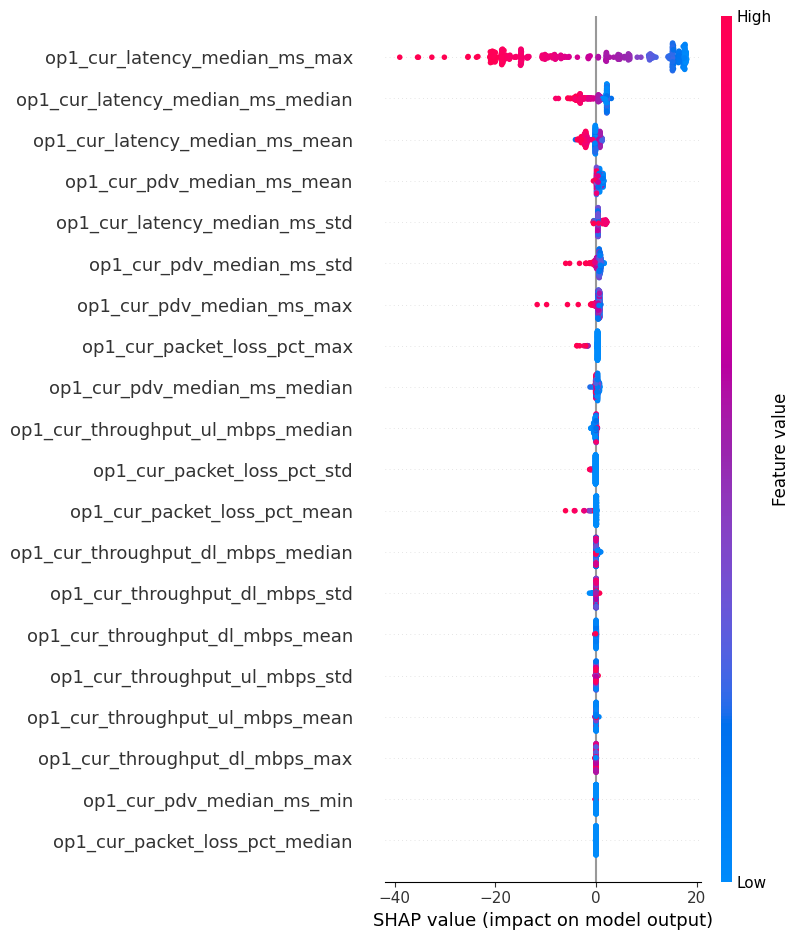

In [69]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

In [71]:
# Check the actual columns in qoe_dataset

print("qoe_dataset columns:")
for i, col in enumerate(qoe_dataset.columns):
    print(i, ":", col)

qoe_dataset columns:
0 : op1_cur_packet_loss_pct_mean
1 : op1_cur_packet_loss_pct_median
2 : op1_cur_packet_loss_pct_min
3 : op1_cur_packet_loss_pct_max
4 : op1_cur_packet_loss_pct_std
5 : op1_cur_latency_median_ms_mean
6 : op1_cur_latency_median_ms_median
7 : op1_cur_latency_median_ms_min
8 : op1_cur_latency_median_ms_max
9 : op1_cur_latency_median_ms_std
10 : op1_cur_pdv_median_ms_mean
11 : op1_cur_pdv_median_ms_median
12 : op1_cur_pdv_median_ms_min
13 : op1_cur_pdv_median_ms_max
14 : op1_cur_pdv_median_ms_std
15 : op1_cur_throughput_ul_mbps_mean
16 : op1_cur_throughput_ul_mbps_median
17 : op1_cur_throughput_ul_mbps_min
18 : op1_cur_throughput_ul_mbps_max
19 : op1_cur_throughput_ul_mbps_std
20 : op1_cur_throughput_dl_mbps_mean
21 : op1_cur_throughput_dl_mbps_median
22 : op1_cur_throughput_dl_mbps_min
23 : op1_cur_throughput_dl_mbps_max
24 : op1_cur_throughput_dl_mbps_std
25 : qoe
26 : timestamp
27 : source_file
28 : scenario
29 : server
30 : window_observations


In [72]:
print("\nShape:", qoe_dataset.shape)
print("\nFirst 5 rows:")
display(qoe_dataset.head())


Shape: (3440, 31)

First 5 rows:


,op1_cur_packet_loss_pct_mean,op1_cur_packet_loss_pct_median,op1_cur_packet_loss_pct_min,op1_cur_packet_loss_pct_max,op1_cur_packet_loss_pct_std,op1_cur_latency_median_ms_mean,op1_cur_latency_median_ms_median,op1_cur_latency_median_ms_min,op1_cur_latency_median_ms_max,op1_cur_latency_median_ms_std,...,op1_cur_throughput_dl_mbps_median,op1_cur_throughput_dl_mbps_min,op1_cur_throughput_dl_mbps_max,op1_cur_throughput_dl_mbps_std,qoe,timestamp,source_file,scenario,server,window_observations
0,0.0,0.0,0.0,0.0,0.0,39.173400,38.9900,36.692,42.672,1.699318,...,0.283655,0.09483,0.88024,0.236218,78.7,03:38:02.452,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,21
1,0.0,0.0,0.0,0.0,0.0,35.350727,38.7450,0.000,41.261,11.783720,...,0.256260,0.00000,0.83370,0.228192,79.9,03:38:21.456,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,22
2,0.0,0.0,0.0,0.0,0.0,35.077250,37.9325,0.000,40.894,11.159157,...,0.220200,0.00000,0.87927,0.232218,80.4,03:38:39.896,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,23
3,0.0,0.0,0.0,0.0,0.0,35.275727,38.8620,0.000,42.450,11.819099,...,0.291560,0.00000,0.98856,0.266452,79.6,03:38:58.986,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,22
4,0.0,0.0,0.0,0.0,0.0,35.385333,38.3005,0.000,41.918,11.220093,...,0.198260,0.00000,0.99859,0.260232,79.8,03:39:17.661,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,Switzerland,23


In [73]:
# ============================================================
# TIME-SERIES DATA PREPARATION
# ============================================================

ts_df = qoe_dataset.copy()

# Sort observations within each source file
ts_df = ts_df.sort_values(
    ["source_file"]
).reset_index(drop=True)

# Create sequential time index within each test file
ts_df["time_index"] = (
    ts_df.groupby("source_file").cumcount() + 1
)

print("Time-series dataset shape:", ts_df.shape)

print("\nColumns added:")
print("time_index")

print("\nExample:")
display(
    ts_df[
        ["source_file", "scenario", "time_index"]
    ].head(10)
)

Time-series dataset shape: (3440, 32)

Columns added:
time_index

Example:


,source_file,scenario,time_index
0,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,1
1,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,2
2,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,3
3,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,4
4,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,5
5,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,6
6,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,7
7,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,8
8,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,9
9,sweden_location_11_is_interactivity_egaming_ch...,Indoor Static,10


In [74]:
print("QoE-related columns:")

for col in qoe_dataset.columns:
    if "interactivity" in col.lower() or "qoe" in col.lower():
        print(col)

QoE-related columns:
qoe


In [75]:
# ============================================================
# TIME-SERIES FORECASTING - CREATE LAG FEATURES
# ============================================================

forecast_df = ts_df.copy()

# Make sure QoE is numeric
forecast_df["qoe"] = pd.to_numeric(
    forecast_df["qoe"],
    errors="coerce"
)

# Sort observations within each test file
forecast_df = forecast_df.sort_values(
    ["source_file", "time_index"]
).reset_index(drop=True)

# Previous QoE values
forecast_df["qoe_lag_1"] = (
    forecast_df.groupby("source_file")["qoe"].shift(1)
)

forecast_df["qoe_lag_2"] = (
    forecast_df.groupby("source_file")["qoe"].shift(2)
)

forecast_df["qoe_lag_3"] = (
    forecast_df.groupby("source_file")["qoe"].shift(3)
)

# Previous QoE average
forecast_df["qoe_rolling_mean_3"] = (
    forecast_df.groupby("source_file")["qoe"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

print("Forecasting dataset shape:", forecast_df.shape)

print("\nExample:")
display(
    forecast_df[
        [
            "source_file",
            "time_index",
            "qoe",
            "qoe_lag_1",
            "qoe_lag_2",
            "qoe_lag_3",
            "qoe_rolling_mean_3"
        ]
    ].head(10)
)

Forecasting dataset shape: (3440, 36)

Example:


,source_file,time_index,qoe,qoe_lag_1,qoe_lag_2,qoe_lag_3,qoe_rolling_mean_3
0,sweden_location_11_is_interactivity_egaming_ch...,1,78.7,NaN,NaN,NaN,NaN
1,sweden_location_11_is_interactivity_egaming_ch...,2,80.4,78.7,NaN,NaN,NaN
2,sweden_location_11_is_interactivity_egaming_ch...,3,79.1,80.4,78.7,NaN,NaN
3,sweden_location_11_is_interactivity_egaming_ch...,4,80.2,79.1,80.4,78.7,79.400000
4,sweden_location_11_is_interactivity_egaming_ch...,5,78.6,80.2,79.1,80.4,79.900000
5,sweden_location_11_is_interactivity_egaming_ch...,6,80.4,78.6,80.2,79.1,79.300000
6,sweden_location_11_is_interactivity_egaming_ch...,7,80.4,80.4,78.6,80.2,79.733333
7,sweden_location_11_is_interactivity_egaming_ch...,8,77.8,80.4,80.4,78.6,79.800000
8,sweden_location_11_is_interactivity_egaming_ch...,9,80.2,77.8,80.4,80.4,79.533333
9,sweden_location_11_is_interactivity_egaming_ch...,10,78.0,80.2,77.8,80.4,79.466667


In [76]:
print("\nMissing values caused by lagging:")

print(
    forecast_df[
        [
            "qoe",
            "qoe_lag_1",
            "qoe_lag_2",
            "qoe_lag_3",
            "qoe_rolling_mean_3"
        ]
    ].isna().sum()
)


Missing values caused by lagging:
qoe                     0
qoe_lag_1             118
qoe_lag_2             236
qoe_lag_3             354
qoe_rolling_mean_3    354
dtype: int64


In [77]:
# ============================================================
# REMOVE ROWS WITHOUT HISTORY
# ============================================================

forecast_clean = forecast_df.dropna(
    subset=[
        "qoe",
        "qoe_lag_1",
        "qoe_lag_2",
        "qoe_lag_3",
        "qoe_rolling_mean_3"
    ]
).copy()

print("Original forecasting dataset:", forecast_df.shape)
print("After removing lag-missing rows:", forecast_clean.shape)

print("\nRemaining missing values:")
print(
    forecast_clean[
        [
            "qoe",
            "qoe_lag_1",
            "qoe_lag_2",
            "qoe_lag_3",
            "qoe_rolling_mean_3"
        ]
    ].isna().sum()
)

Original forecasting dataset: (3440, 36)
After removing lag-missing rows: (3086, 36)

Remaining missing values:
qoe                   0
qoe_lag_1             0
qoe_lag_2             0
qoe_lag_3             0
qoe_rolling_mean_3    0
dtype: int64


In [78]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

train_parts = []
test_parts = []

for source, group in forecast_clean.groupby("source_file"):

    group = group.sort_values("time_index").reset_index(drop=True)

    split_point = int(len(group) * 0.80)

    train_parts.append(group.iloc[:split_point])
    test_parts.append(group.iloc[split_point:])

forecast_train = pd.concat(
    train_parts,
    ignore_index=True
)

forecast_test = pd.concat(
    test_parts,
    ignore_index=True
)

print("Training samples:", len(forecast_train))
print("Testing samples:", len(forecast_test))

print("\nTrain/Test ratio:")
print(
    len(forecast_train) /
    (len(forecast_train) + len(forecast_test))
)

Training samples: 2420
Testing samples: 666

Train/Test ratio:
0.7841866493843163


In [79]:
# ============================================================
# TRAIN TIME-SERIES FORECASTING MODEL
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forecast_features = [
    "qoe_lag_1",
    "qoe_lag_2",
    "qoe_lag_3",
    "qoe_rolling_mean_3"
]

X_forecast_train = forecast_train[forecast_features]
y_forecast_train = forecast_train["qoe"]

X_forecast_test = forecast_test[forecast_features]
y_forecast_test = forecast_test["qoe"]

forecast_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

forecast_model.fit(
    X_forecast_train,
    y_forecast_train
)

print("Time-series forecasting model trained successfully!")

Time-series forecasting model trained successfully!


In [80]:
# ============================================================
# FORECASTING PERFORMANCE
# ============================================================

y_forecast_pred = forecast_model.predict(
    X_forecast_test
)

forecast_mae = mean_absolute_error(
    y_forecast_test,
    y_forecast_pred
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        y_forecast_test,
        y_forecast_pred
    )
)

forecast_r2 = r2_score(
    y_forecast_test,
    y_forecast_pred
)

print("Time-Series Forecasting Results")
print("--------------------------------")
print(f"MAE  : {forecast_mae:.4f}")
print(f"RMSE : {forecast_rmse:.4f}")
print(f"R²   : {forecast_r2:.4f}")

Time-Series Forecasting Results
--------------------------------
MAE  : 4.7799
RMSE : 10.0686
R²   : 0.8121


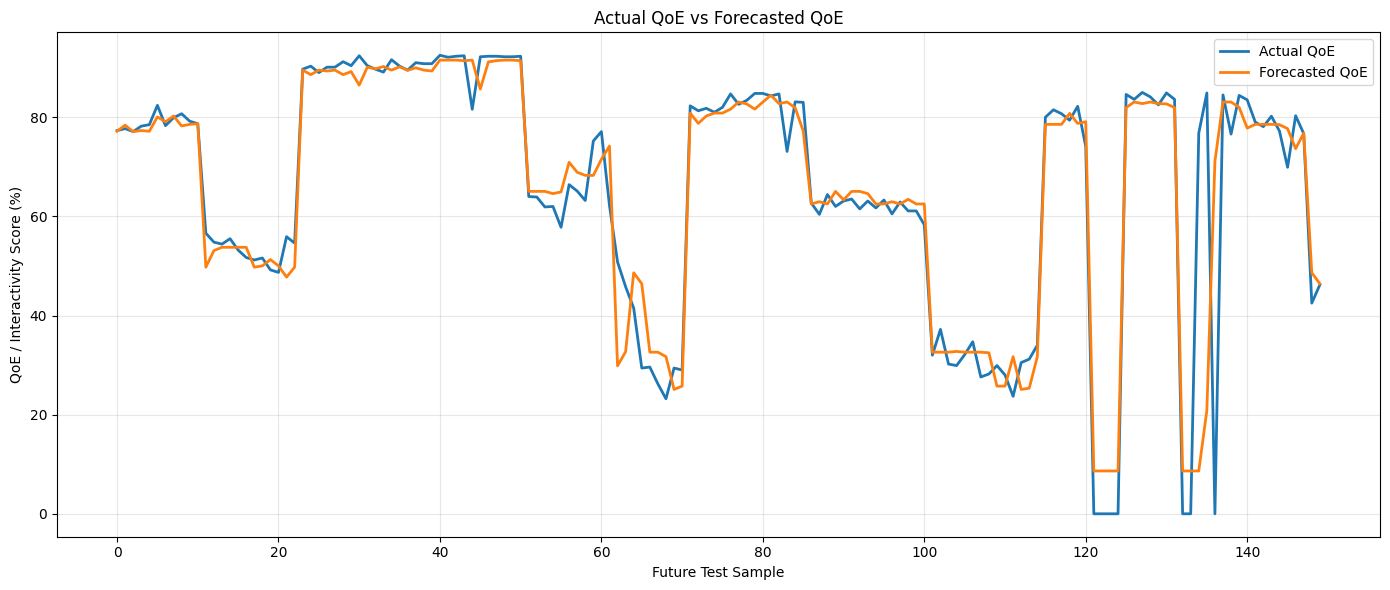

Graph saved to:
..\results\plots\qoe_forecast_actual_vs_predicted.png


In [81]:
# ============================================================
# ACTUAL QoE vs FORECASTED QoE
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

# Create results/plots folder if it does not exist
PLOT_DIR = Path("../results/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Use first 150 test samples for a readable graph
n_samples = min(150, len(y_forecast_test))

actual = y_forecast_test.iloc[:n_samples].reset_index(drop=True)
predicted = y_forecast_pred[:n_samples]

plt.figure(figsize=(14, 6))

plt.plot(
    actual,
    label="Actual QoE",
    linewidth=2
)

plt.plot(
    predicted,
    label="Forecasted QoE",
    linewidth=2
)

plt.xlabel("Future Test Sample")
plt.ylabel("QoE / Interactivity Score (%)")
plt.title("Actual QoE vs Forecasted QoE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save graph
plot_path = PLOT_DIR / "qoe_forecast_actual_vs_predicted.png"

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved to:")
print(plot_path)

In [82]:
# ============================================================
# XAI - SHAP EXPLANATION FOR QoE PREDICTION
# ============================================================

import shap
import matplotlib.pyplot as plt

print("Creating SHAP explanation...")

# Use a small sample of validation/test data
X_shap = X_val.sample(
    min(300, len(X_val)),
    random_state=42
)

# Create SHAP explainer
explainer = shap.Explainer(rf_model, X_shap)

# Calculate SHAP values
shap_values = explainer(X_shap)

print("SHAP explanation generated successfully!")
print("Number of samples:", len(X_shap))
print("Number of features:", X_shap.shape[1])

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


Creating SHAP explanation...
SHAP explanation generated successfully!
Number of samples: 300
Number of features: 25


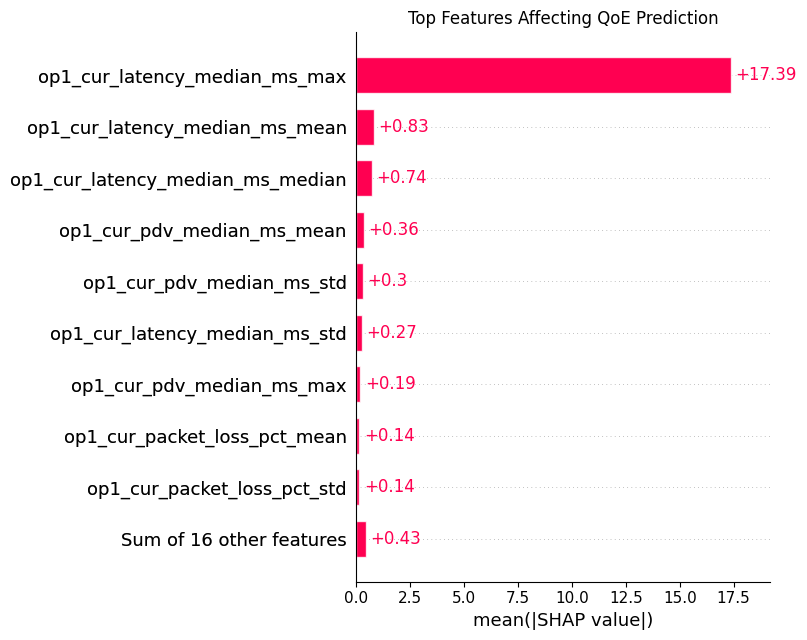

SHAP graph saved to:
..\results\plots\shap_qoe_feature_importance.png


In [83]:
# ============================================================
# SHAP FEATURE IMPORTANCE
# ============================================================

plt.figure()

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title("Top Features Affecting QoE Prediction")
plt.tight_layout()

shap_path = PLOT_DIR / "shap_qoe_feature_importance.png"

plt.savefig(
    shap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP graph saved to:")
print(shap_path)

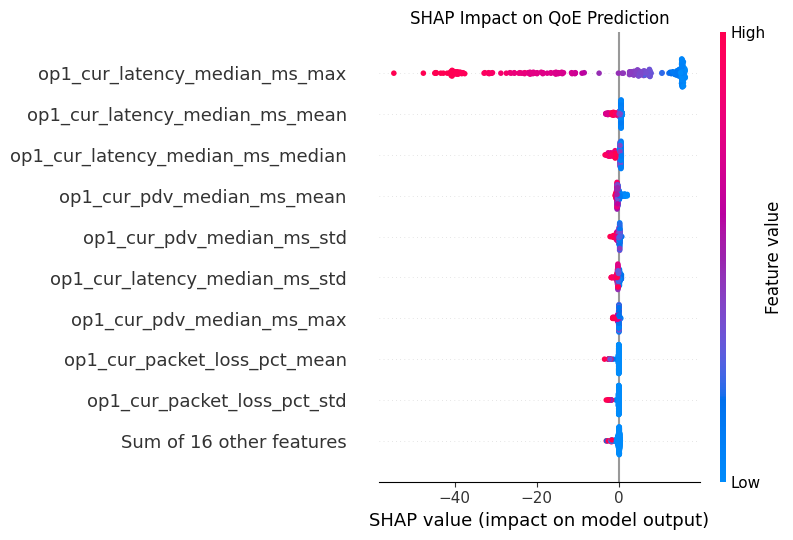

SHAP direction graph saved to:
..\results\plots\shap_qoe_impact_direction.png


In [84]:
# ============================================================
# SHAP - FEATURE IMPACT DIRECTION
# ============================================================

plt.figure()

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title("SHAP Impact on QoE Prediction")
plt.tight_layout()

direction_path = PLOT_DIR / "shap_qoe_impact_direction.png"

plt.savefig(
    direction_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP direction graph saved to:")
print(direction_path)

In [86]:
# ============================================================
# SAVE FINAL QoE MODEL
# ============================================================

from pathlib import Path
import joblib

# Project folders
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save Gradient Boosting model
model_path = MODEL_DIR / "qoe_gradient_boosting.pkl"
joblib.dump(gb_model, model_path)

# Save the exact feature names used by the model
features_path = MODEL_DIR / "qoe_features.pkl"
joblib.dump(list(X_train.columns), features_path)

print("Model saved successfully!")
print()
print("Model file:")
print(model_path)

print()
print("Feature list:")
print(features_path)

print()
print("Number of features:", len(X_train.columns))

Model saved successfully!

Model file:
..\models\qoe_gradient_boosting.pkl

Feature list:
..\models\qoe_features.pkl

Number of features: 25


In [87]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

loaded_model = joblib.load(model_path)
loaded_features = joblib.load(features_path)

print("Model loaded successfully!")
print("Model type:", type(loaded_model).__name__)
print("Number of features:", len(loaded_features))

print("\nFeatures:")
for feature in loaded_features:
    print("-", feature)

Model loaded successfully!
Model type: GradientBoostingRegressor
Number of features: 25

Features:
- op1_cur_packet_loss_pct_mean
- op1_cur_packet_loss_pct_median
- op1_cur_packet_loss_pct_min
- op1_cur_packet_loss_pct_max
- op1_cur_packet_loss_pct_std
- op1_cur_latency_median_ms_mean
- op1_cur_latency_median_ms_median
- op1_cur_latency_median_ms_min
- op1_cur_latency_median_ms_max
- op1_cur_latency_median_ms_std
- op1_cur_pdv_median_ms_mean
- op1_cur_pdv_median_ms_median
- op1_cur_pdv_median_ms_min
- op1_cur_pdv_median_ms_max
- op1_cur_pdv_median_ms_std
- op1_cur_throughput_ul_mbps_mean
- op1_cur_throughput_ul_mbps_median
- op1_cur_throughput_ul_mbps_min
- op1_cur_throughput_ul_mbps_max
- op1_cur_throughput_ul_mbps_std
- op1_cur_throughput_dl_mbps_mean
- op1_cur_throughput_dl_mbps_median
- op1_cur_throughput_dl_mbps_min
- op1_cur_throughput_dl_mbps_max
- op1_cur_throughput_dl_mbps_std


In [89]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")

feature_columns = joblib.load(
    MODEL_DIR / "qoe_features.pkl"
)

print("NUMBER OF FEATURES:", len(feature_columns))

print("\nFEATURE COLUMNS:")
for i, col in enumerate(feature_columns):
    print(i, ":", col)

NUMBER OF FEATURES: 25

FEATURE COLUMNS:
0 : op1_cur_packet_loss_pct_mean
1 : op1_cur_packet_loss_pct_median
2 : op1_cur_packet_loss_pct_min
3 : op1_cur_packet_loss_pct_max
4 : op1_cur_packet_loss_pct_std
5 : op1_cur_latency_median_ms_mean
6 : op1_cur_latency_median_ms_median
7 : op1_cur_latency_median_ms_min
8 : op1_cur_latency_median_ms_max
9 : op1_cur_latency_median_ms_std
10 : op1_cur_pdv_median_ms_mean
11 : op1_cur_pdv_median_ms_median
12 : op1_cur_pdv_median_ms_min
13 : op1_cur_pdv_median_ms_max
14 : op1_cur_pdv_median_ms_std
15 : op1_cur_throughput_ul_mbps_mean
16 : op1_cur_throughput_ul_mbps_median
17 : op1_cur_throughput_ul_mbps_min
18 : op1_cur_throughput_ul_mbps_max
19 : op1_cur_throughput_ul_mbps_std
20 : op1_cur_throughput_dl_mbps_mean
21 : op1_cur_throughput_dl_mbps_median
22 : op1_cur_throughput_dl_mbps_min
23 : op1_cur_throughput_dl_mbps_max
24 : op1_cur_throughput_dl_mbps_std


In [91]:
# Check the QoE column
print("QoE columns:")
print(qoe_dataset.columns.tolist())

QoE columns:
['op1_cur_packet_loss_pct_mean', 'op1_cur_packet_loss_pct_median', 'op1_cur_packet_loss_pct_min', 'op1_cur_packet_loss_pct_max', 'op1_cur_packet_loss_pct_std', 'op1_cur_latency_median_ms_mean', 'op1_cur_latency_median_ms_median', 'op1_cur_latency_median_ms_min', 'op1_cur_latency_median_ms_max', 'op1_cur_latency_median_ms_std', 'op1_cur_pdv_median_ms_mean', 'op1_cur_pdv_median_ms_median', 'op1_cur_pdv_median_ms_min', 'op1_cur_pdv_median_ms_max', 'op1_cur_pdv_median_ms_std', 'op1_cur_throughput_ul_mbps_mean', 'op1_cur_throughput_ul_mbps_median', 'op1_cur_throughput_ul_mbps_min', 'op1_cur_throughput_ul_mbps_max', 'op1_cur_throughput_ul_mbps_std', 'op1_cur_throughput_dl_mbps_mean', 'op1_cur_throughput_dl_mbps_median', 'op1_cur_throughput_dl_mbps_min', 'op1_cur_throughput_dl_mbps_max', 'op1_cur_throughput_dl_mbps_std', 'qoe', 'timestamp', 'source_file', 'scenario', 'server', 'window_observations']


In [96]:
from pathlib import Path
import sys

# Make sure src folder is available
sys.path.append("../src")

from forecasting import forecast_summary

# Use the actual QoE dataset
qoe_series = (
    pd.to_numeric(
        qoe_dataset["qoe"],
        errors="coerce"
    )
    .dropna()
    .reset_index(drop=True)
)

print("Number of QoE observations:", len(qoe_series))
print("First 10 QoE values:")
print(qoe_series.head(10))

# Forecast
result = forecast_summary(
    qoe_series,
    horizon=10
)

print("\n")
print("QoE FORECAST RESULT")
print("--------------------")

print("Current QoE:", result["current_qoe"])
print("Future QoE:", result["future_qoe"])
print("Trend:", result["trend"])

print("\nForecast values:")
print(result["forecast_values"])

Number of QoE observations: 3440
First 10 QoE values:
0    78.7
1    79.9
2    80.4
3    79.6
4    79.8
5    77.4
6    78.5
7    77.3
8    77.7
9    77.1
Name: qoe, dtype: float64


QoE FORECAST RESULT
--------------------
Current QoE: 83.5
Future QoE: 76.39768960614504
Trend: Declining

Forecast values:
[82.60440614 81.2640251  80.07545879 79.69994202 78.84468396 78.56851702
 77.19603682 76.39768961 76.39768961 76.39768961]
